# Physical-validation tests

Companion to the algebraic / synthetic unit tests in `tests/test_jacobian.py`
(Cases A–G) and `tests/test_mld.py`.  Those tests prove the code is
*internally* correct — it reproduces a known closed-form answer to machine
precision.  They cannot tell us whether the **physics** of a globally computed
field is right.

This notebook does the complementary check: it compares our computed fields
against **independent knowledge from the published literature** — first by
visual inspection of global maps, and (in later sections, to be added after
discussion) by area-averaged / distributional statistics.  These are
*qualitative and statistical* validations, not bit-exact assertions.

---

## Test 1 — Mixed-layer depth vs. Sallée et al. (2021)

We plot our LLC4320-derived `mixed_layer_depth` next to **Fig. 2f** of:

> Sallée, J.-B., Pellichero, V., Akhoudas, C., Pauthenet, E., Vignes, L.,
> Schmidtko, S., Garabato, A. N., Sutherland, P., & Kuusela, M. (2021).
> *Summertime increases in upper-ocean stratification and mixed-layer depth.*
> **Nature, 591**, 592–598. https://doi.org/10.1038/s41586-021-03303-x

**What a "pass" looks like.** The large-scale geography of the mixed layer
should match the observational climatology: deep mixed layers in the subpolar
North Atlantic / Nordic Seas and around the Antarctic Circumpolar Current
(Southern Ocean), and shallow mixed layers across the tropics and subtropical
gyres.  We are *not* expecting point-by-point agreement.

**Important caveat (read before interpreting).** Our field is a **single
instantaneous snapshot** (`date_prefix` in the access config, e.g.
2012-11-09 12:00 UTC), whereas the Sallée et al. map is an **observational
climatology**.  A single snapshot also carries vigorous submesoscale structure
that a climatology averages away, and the hemispheric season is fixed by the
snapshot date (early NH winter / late SH spring in November).  So compare the
*basin-scale pattern and order of magnitude*, not the fine structure or the
exact deep/shallow contrast.

### Data access

This mirrors `notebooks/notebooks_global/assess_generate_global_script.ipynb`:
it reads the `stratification` subset written by `generate-global` (DEPTH
pipeline) from S3, using the coordinates in `configs/global/access.yaml`.

**Requirements** (same as the assess notebook):
- a completed `stratification` run whose `run_id` / `date_prefix` are set in
  `configs/global/access.yaml`;
- AWS S3 credentials in the environment (`AWS_ACCESS_KEY_ID`,
  `AWS_SECRET_ACCESS_KEY`);
- `cartopy` and `cmocean` installed for the maps.

The cell that reaches out to S3 will only work in an environment with network
+ credentials (e.g. NRP Jupyterhub), exactly like the assess notebook.

In [1]:
# Imports (mirrors the assess notebook).
import os

import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.image as mpimg
import cmocean.cm as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import dbof.global_dataset_creation.zarr_dataset_global as zarr_dataset
import dbof.global_dataset_creation.zarr_grid_global    as zarr_grid
import dbof.io.filesystems as filesystems
from dbof.global_dataset_creation.subset_definitions import get_subset_definition
from dbof.global_dataset_creation.subset_definitions import expand_channels_with_suffixes

In [3]:
# ── Load access config (S3 coordinates only) ─────────────────────────────────
# The MLD lives in the 'stratification' subset of the DEPTH pipeline.
SUBSET = 'stratification'
MLD_CHANNEL = 'mixed_layer_depth'   # cmocean 'deep', units: metres

path_to_config = "../../configs/global/access.yaml"
with open(path_to_config) as f:
    cfg = yaml.safe_load(f)

pipeline = cfg.get("pipeline", "DEPTH")
data_cfg = cfg["data_access"]
grid_cfg = cfg["grid_access"]

bucket      = data_cfg["bucket"]
folder      = data_cfg["folder"]
s3_endpoint = data_cfg["s3_endpoint"]
run_id      = data_cfg["run_id"]
date_prefix = data_cfg["date_prefix"]

defn = get_subset_definition(pipeline, SUBSET)
dataset_name = defn["dataset_name"]

grid_bucket       = grid_cfg["bucket"]
grid_folder       = grid_cfg["folder"]
grid_s3_endpoint  = grid_cfg["s3_endpoint"]
grid_dataset_name = grid_cfg["dataset_name"]

print(f"Pipeline   : {pipeline}")
print(f"Subset     : {SUBSET}")
print(f"Snapshot   : s3://{bucket}/{folder}/{run_id}/{date_prefix}/{dataset_name}")
print(f"Grid       : s3://{grid_bucket}/{grid_folder}/{grid_dataset_name}")
print(f"MLD channel: {MLD_CHANNEL}")
print(f"Date       : {date_prefix}  (single snapshot — see caveat above)")

Pipeline   : DEPTH
Subset     : stratification
Snapshot   : s3://dbof/depth_fields/V4/20121109_120000/stratification.zarr
Grid       : s3://dbof/native_grid_dbof_training_data/llc4320_grid.zarr
MLD channel: mixed_layer_depth
Date       : 20121109_120000  (single snapshot — see caveat above)


In [4]:
# ── Open the dataset + grid readers and pull the MLD snapshot ────────────────
fs, _ = filesystems.create_s3_filesystems(s3_endpoint)
reader = zarr_dataset.GlobalZarrDatasetReader(
    bucket=bucket, folder=folder, run_id=run_id,
    dataset_name=dataset_name, date_prefix=date_prefix, fs=fs,
)
print(reader)
print(f"Channels : {reader.channel_names}")

assert MLD_CHANNEL in reader.channel_names, (
    f"'{MLD_CHANNEL}' not in this subset. Available: {reader.channel_names}")

fs_grid, _ = filesystems.create_s3_filesystems(grid_s3_endpoint)
grid_reader = zarr_grid.GlobalGridZarrReader(
    bucket=grid_bucket, folder=grid_folder,
    dataset_name=grid_dataset_name, fs=fs_grid,
)

XC = grid_reader.lon
YC = grid_reader.lat

DS_GLOBAL = 20                       # display downsample, as in the assess nb
XC_g = XC[::DS_GLOBAL, ::DS_GLOBAL]
YC_g = YC[::DS_GLOBAL, ::DS_GLOBAL]

timestep = 0
mld = reader.get_channel_snapshot(timestep, MLD_CHANNEL)[::DS_GLOBAL, ::DS_GLOBAL]
finite = mld[np.isfinite(mld)]
print(f"MLD snapshot: shape {mld.shape}, "
      f"range [{finite.min():.1f}, {finite.max():.1f}] m, "
      f"median {np.median(finite):.1f} m")

Channels : ['N2_sfc', 'N2_z25m', 'N2_mld', 'N2_mld_mean', 'mixed_layer_depth', 'ml_heat_content']
MLD snapshot: shape (648, 864), range [9.7, 945.6] m, median 45.9 m


### The literature figure

Copyright prevents bundling the published figure in the repo, so this notebook
loads it from a **local image file you provide**.  Save Fig. 2f from Sallée et
al. (2021) as:

```
notebooks/notebooks_tests/sallee2021_fig2f.png
```

If the file is absent the right-hand panel shows a placeholder so the rest of
the notebook still runs.

In [ ]:
# Path to the literature figure (place it next to this notebook).
LIT_FIG_PATH = "/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/testing/physical_validation/sallee2021_fig2f.png"
LIT_FIG_CITATION = ("Sallée et al. (2021), Fig. 2f\n"
                    "doi:10.1038/s41586-021-03303-x")
lit_img = mpimg.imread(LIT_FIG_PATH) if os.path.exists(LIT_FIG_PATH) else None
print("literature figure found" if lit_img is not None
      else f"NOTE: {LIT_FIG_PATH} not found — placeholder will be shown.")

literature figure found


/Users/lahoffma/miniforge3/envs/fronts/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


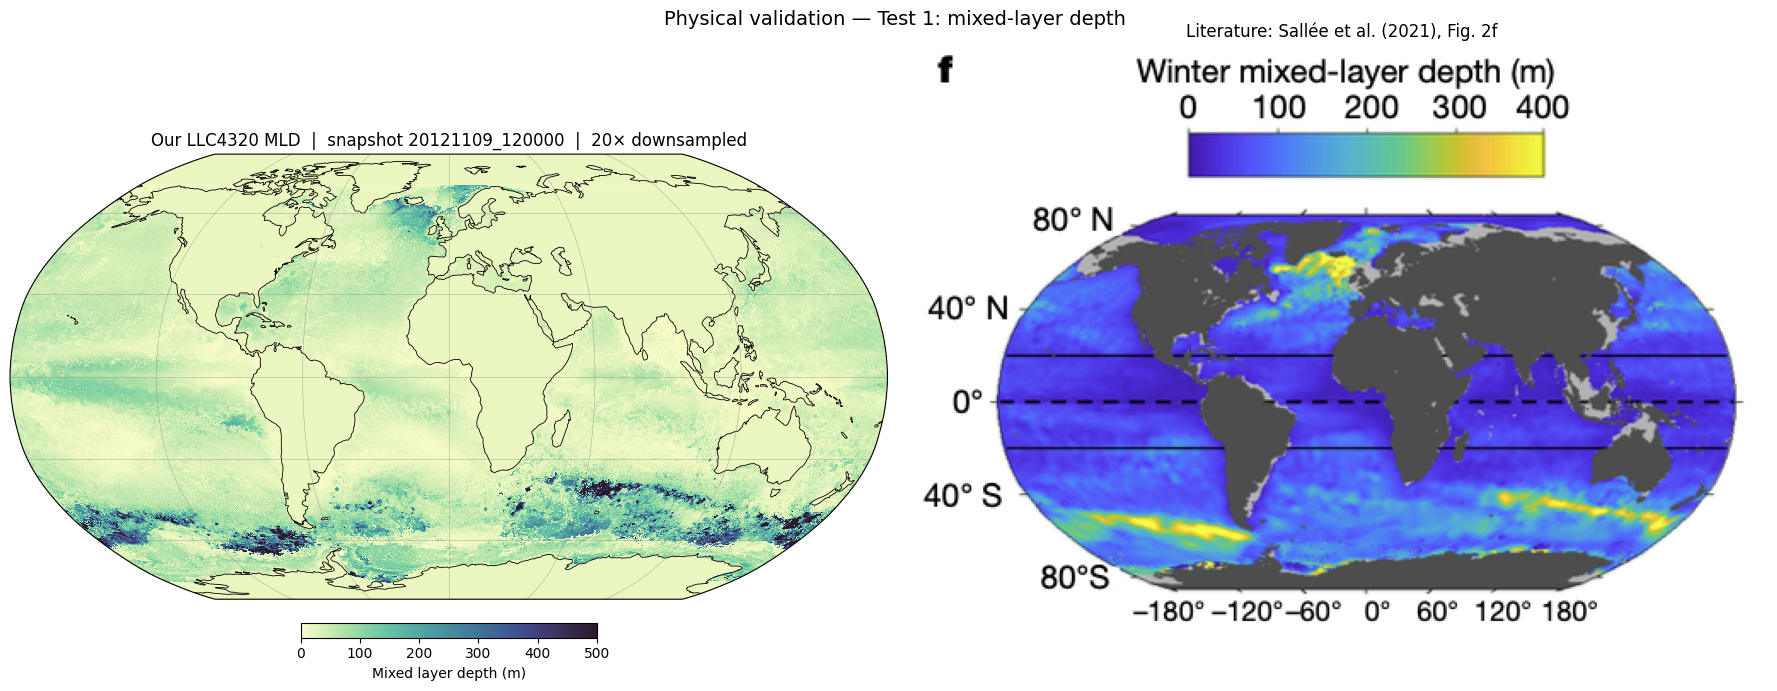

In [10]:
# ── Side-by-side: our MLD (left) vs. literature (right) ──────────────────────
# Fixed 0–500 m range so the deep subpolar / Southern-Ocean signal is visible;
# adjust VMAX to match the colourbar of the literature panel if desired.
VMAX = 500.0

fig = plt.figure(figsize=(18, 7))

# Left: our LLC4320 MLD on a Robinson projection.
axL = fig.add_subplot(1, 2, 1, projection=ccrs.Robinson())
im = axL.pcolormesh(XC_g, YC_g, np.clip(mld, 0, VMAX),
                    cmap=cmo.deep, vmin=0, vmax=VMAX,
                    transform=ccrs.PlateCarree(), shading='nearest')
axL.add_feature(cfeature.COASTLINE, linewidth=0.6, color='k')
axL.gridlines(linewidth=0.4, color='gray', alpha=0.6)
plt.colorbar(im, ax=axL, fraction=0.025, pad=0.04, shrink=0.7,
             orientation='horizontal', label='Mixed layer depth (m)')
axL.set_title(f'Our LLC4320 MLD  |  snapshot {date_prefix}  |  {DS_GLOBAL}× downsampled')

# Right: the published figure (or a placeholder).
axR = fig.add_subplot(1, 2, 2)
if lit_img is not None:
    axR.imshow(lit_img)
    axR.set_title('Literature: ' + LIT_FIG_CITATION.split(chr(10))[0])
else:
    axR.text(0.5, 0.5, f'Place\n{LIT_FIG_PATH}\nnext to this notebook',
             ha='center', va='center', fontsize=12)
    axR.set_title('Literature panel (missing)')
axR.axis('off')

fig.suptitle('Physical validation — Test 1: mixed-layer depth', fontsize=14)
fig.tight_layout()
plt.show()

### What to look for

Reading the two panels together:

- **Deep mixed layers** (bright) should appear in the **subpolar North
  Atlantic / Nordic Seas** and along the **Antarctic Circumpolar Current** in
  the Southern Ocean — the regions of strong wintertime convection.
- **Shallow mixed layers** (dark) should dominate the **tropics** and the
  **subtropical gyres**, where the water column is strongly stratified.
- The **order of magnitude** should match: tens of metres in the tropics,
  hundreds of metres in the deep-convection regions.

Departures to expect (and *not* treat as failures): our single November
snapshot makes the Northern Hemisphere look deeper and the Southern Hemisphere
shallower than an annual climatology, and the snapshot retains submesoscale
filaments that the climatology smooths out. A genuine red flag would be
qualitatively wrong geography — e.g. the deepest mixed layers landing in the
tropics, or values orders of magnitude off.